Importing libraries required for Wine Quality Prediction.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [2]:
# Importing the Data
Redwine= pd.read_csv("winequality-red.csv", delimiter=';')
Whitewine= pd.read_csv("winequality-white.csv", delimiter=';')

In [3]:
Winedata = pd.concat([Redwine, Whitewine])
Winedata

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


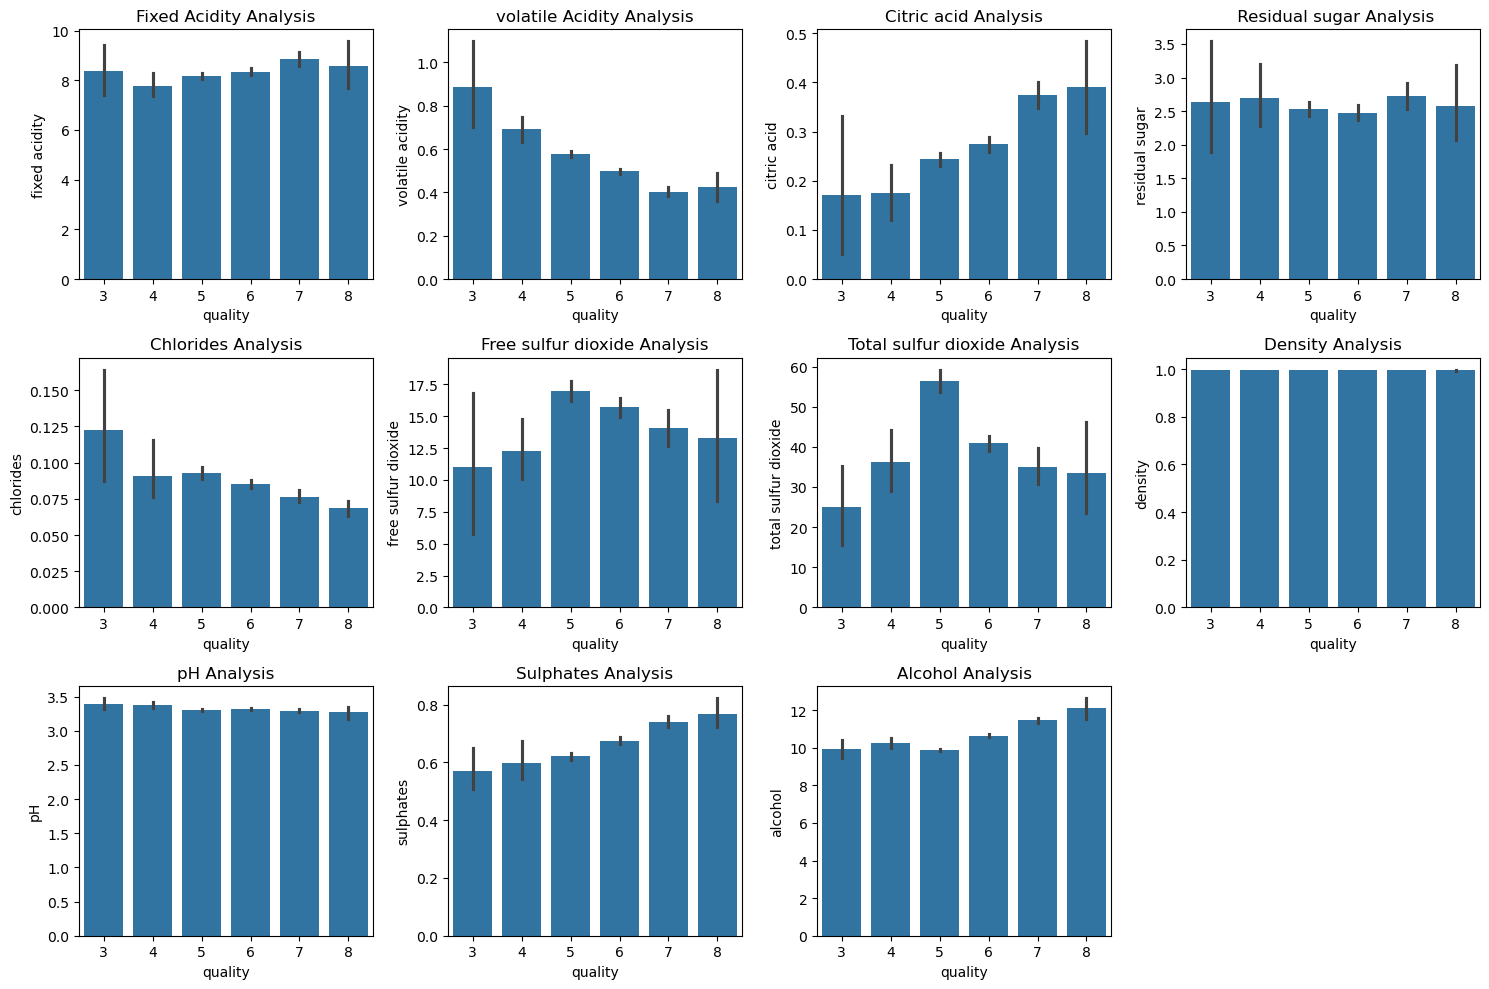

In [4]:
fig = plt.figure(figsize=(15,10))

plt.subplot(3,4,1)
sns.barplot(x='quality',y='fixed acidity',data=Redwine)
plt.title('Fixed Acidity Analysis')

plt.subplot(3,4,2)
sns.barplot(x='quality',y='volatile acidity',data=Redwine)
plt.title('volatile Acidity Analysis')

plt.subplot(3,4,3)
sns.barplot(x='quality',y='citric acid',data=Redwine)
plt.title('Citric acid Analysis')

plt.subplot(3,4,4)
sns.barplot(x='quality',y='residual sugar',data=Redwine)
plt.title(' Residual sugar Analysis')

plt.subplot(3,4,5)
sns.barplot(x='quality',y='chlorides',data=Redwine)
plt.title('Chlorides Analysis')

plt.subplot(3,4,6)
sns.barplot(x='quality',y='free sulfur dioxide',data=Redwine)
plt.title('Free sulfur dioxide Analysis')

plt.subplot(3,4,7)
sns.barplot(x='quality',y='total sulfur dioxide',data=Redwine)
plt.title('Total sulfur dioxide Analysis')

plt.subplot(3,4,8)
sns.barplot(x='quality',y='density',data=Redwine)
plt.title('Density Analysis')

plt.subplot(3,4,9)
sns.barplot(x='quality',y='pH',data=Redwine)
plt.title('pH Analysis')

plt.subplot(3,4,10)
sns.barplot(x='quality',y='sulphates',data=Redwine)
plt.title('Sulphates Analysis')

plt.subplot(3,4,11)
sns.barplot(x='quality',y='alcohol',data=Redwine)
plt.title('Alcohol Analysis')

plt.tight_layout()

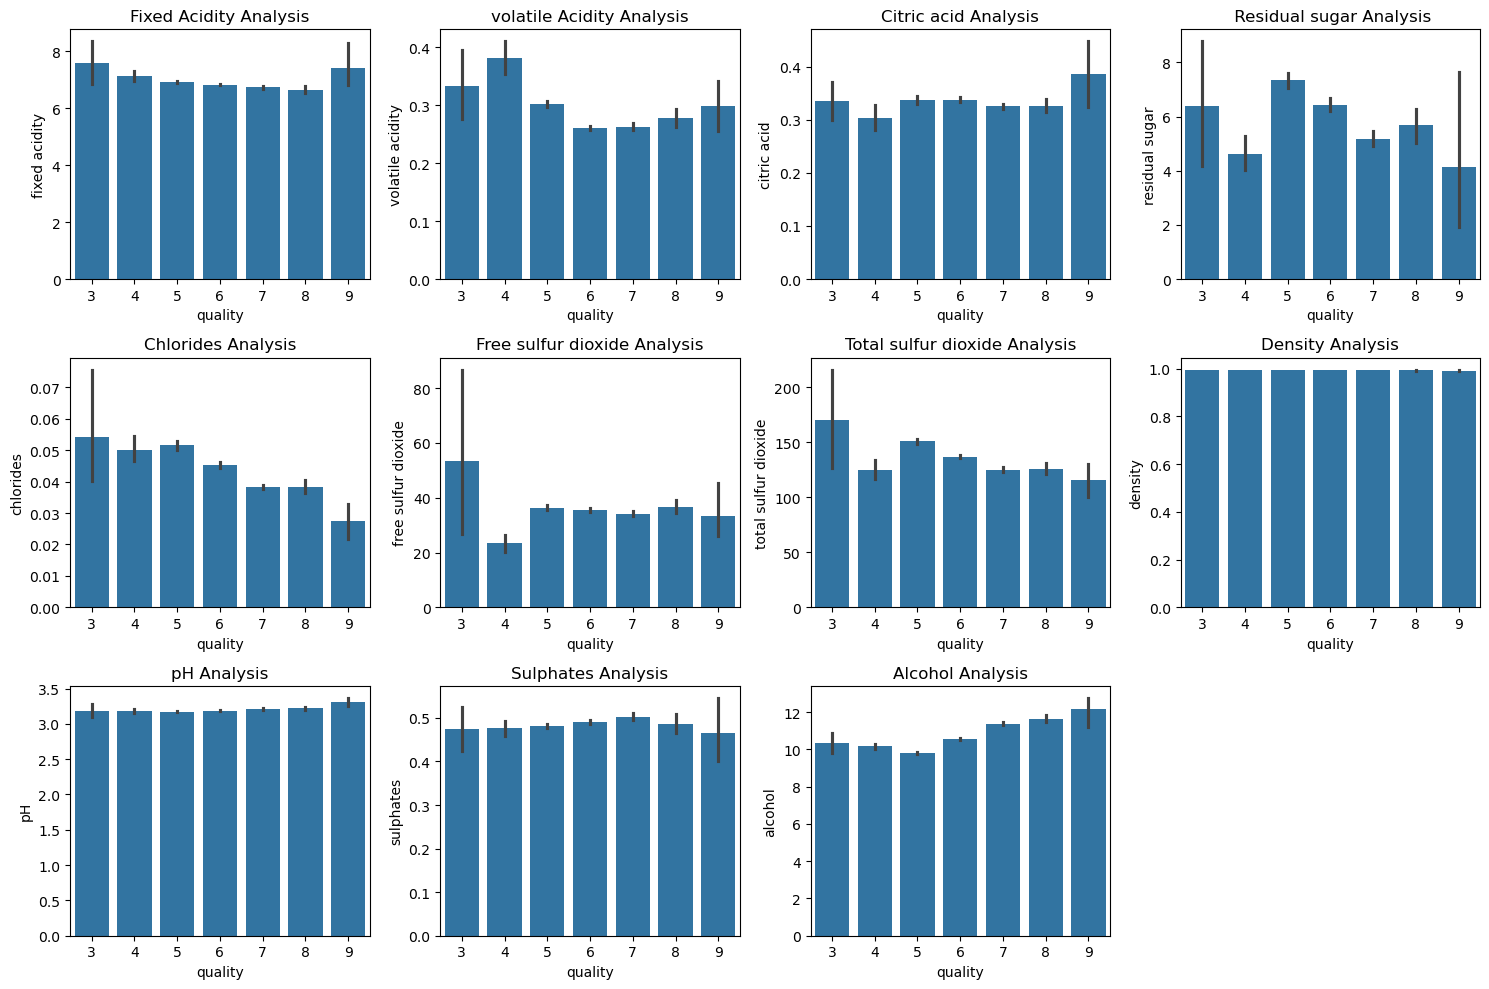

In [5]:
fig = plt.figure(figsize=(15,10))

plt.subplot(3,4,1)
sns.barplot(x='quality',y='fixed acidity',data=Whitewine)
plt.title('Fixed Acidity Analysis')

plt.subplot(3,4,2)
sns.barplot(x='quality',y='volatile acidity',data=Whitewine)
plt.title('volatile Acidity Analysis')

plt.subplot(3,4,3)
sns.barplot(x='quality',y='citric acid',data=Whitewine)
plt.title('Citric acid Analysis')

plt.subplot(3,4,4)
sns.barplot(x='quality',y='residual sugar',data=Whitewine)
plt.title(' Residual sugar Analysis')

plt.subplot(3,4,5)
sns.barplot(x='quality',y='chlorides',data=Whitewine)
plt.title('Chlorides Analysis')

plt.subplot(3,4,6)
sns.barplot(x='quality',y='free sulfur dioxide',data=Whitewine)
plt.title('Free sulfur dioxide Analysis')

plt.subplot(3,4,7)
sns.barplot(x='quality',y='total sulfur dioxide',data=Whitewine)
plt.title('Total sulfur dioxide Analysis')

plt.subplot(3,4,8)
sns.barplot(x='quality',y='density',data=Whitewine)
plt.title('Density Analysis')

plt.subplot(3,4,9)
sns.barplot(x='quality',y='pH',data=Whitewine)
plt.title('pH Analysis')

plt.subplot(3,4,10)
sns.barplot(x='quality',y='sulphates',data=Whitewine)
plt.title('Sulphates Analysis')

plt.subplot(3,4,11)
sns.barplot(x='quality',y='alcohol',data=Whitewine)
plt.title('Alcohol Analysis')

plt.tight_layout()

In [6]:
red_value = ['red']
Redwine['type'] = red_value * 1599
white_value = ['white']
Whitewine ['type'] =white_value * 4898 

In [7]:
# we are creating a new column called "quality_label", we define a range and associate that range with a label
Redwine['quality_label'] = Redwine['quality'].apply(lambda value: 'low'
if value <= 6 else 'high')

# here we are transforming these labels into a categorical data type (specific to pandas) instead of a simple string
Redwine['quality_label'] = pd.Categorical(Redwine['quality_label'],
categories=['low','high'])
Redwine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,quality_label
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red,low
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red,low
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red,low
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red,low
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,red,low
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,red,low
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,red,low
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,red,low


In [8]:
# we are creating a new column called "quality_label", we define a range and associate that range with a label
Whitewine['quality_label'] = Whitewine['quality'].apply(lambda value: 'low'
if value <=  6 else 'high')

# here we are transforming these labels into a categorical data type (specific to pandas) instead of a simple string
Whitewine['quality_label'] = pd.Categorical(Whitewine['quality_label'],
categories=['low','high'])
Whitewine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,quality_label
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,white,low
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,white,low
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,white,low
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,white,low
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,white,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white,low
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white,low
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white,low
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white,high


In [9]:
Winedata = pd.concat([Redwine, Whitewine])
Winedata

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red,low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red,low
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red,low
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red,low
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white,low
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white,low
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white,low
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white,high


In [10]:
ranges = (2,6.5,8) 
groups = ['bad','good']
Winedata['quality'] = pd.cut(Winedata['quality'],bins=ranges,labels=groups)


In [11]:
le = LabelEncoder()
Winedata['quality'] = le.fit_transform(Winedata['quality'])
Winedata.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,red,low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,red,low
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,red,low
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,red,low
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,red,low


In [12]:
le = LabelEncoder()
Winedata['type'] = le.fit_transform(Winedata['type'])
Winedata.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,0,low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,0,low
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,0,low
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,0,low
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,0,low


In [13]:
le = LabelEncoder()
Winedata['quality_label'] = le.fit_transform(Winedata['quality_label'])
Winedata.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,0,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,0,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,0,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,0,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,0,1


In [14]:
Winedata['quality'].value_counts()

quality
0    5220
1    1272
2       5
Name: count, dtype: int64

In [15]:
good_quality = Winedata[Winedata['quality']==1]
bad_quality = Winedata[Winedata['quality']==0]

bad_quality = bad_quality.sample(frac=1)
bad_quality = bad_quality[:1272]

new_df = pd.concat([good_quality,bad_quality])
new_df = new_df.sample(frac=1)
new_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,quality_label
1320,7.6,0.190,0.42,1.5,0.044,6.0,114.0,0.99140,3.04,0.74,12.80,0,1,1
4493,6.8,0.310,0.25,10.5,0.043,30.0,165.0,0.99720,3.36,0.55,10.55,0,1,1
3912,6.5,0.330,0.30,3.8,0.036,34.0,88.0,0.99028,3.25,0.63,12.50,1,1,0
3850,6.7,0.240,0.32,9.0,0.023,20.0,109.0,0.99262,3.34,0.35,12.60,0,1,1
372,6.6,0.905,0.19,0.8,0.048,17.0,204.0,0.99340,3.34,0.56,10.00,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1816,6.7,0.270,0.30,13.9,0.029,34.0,131.0,0.99530,3.36,0.50,12.00,1,1,0
618,11.4,0.460,0.50,2.7,0.122,4.0,17.0,1.00060,3.13,0.70,10.20,0,0,1
1868,7.4,0.210,0.27,7.3,0.031,41.0,144.0,0.99320,3.15,0.38,11.80,1,1,0
146,5.8,0.680,0.02,1.8,0.087,21.0,94.0,0.99440,3.54,0.52,10.00,0,0,1


In [16]:
new_df['quality'].value_counts()

quality
0    1272
1    1272
Name: count, dtype: int64

In [17]:
new_df.corr()['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.430853
type                    0.101897
citric acid             0.064762
sulphates               0.034054
free sulfur dioxide     0.030514
pH                      0.020227
fixed acidity          -0.051097
residual sugar         -0.069826
total sulfur dioxide   -0.079678
volatile acidity       -0.200641
chlorides              -0.236557
density                -0.315585
quality_label          -1.000000
Name: quality, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split

X = new_df.drop('quality',axis=1) 
y = new_df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
Winedata['quality'].value_counts()

quality
0    5220
1    1272
2       5
Name: count, dtype: int64

In [20]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000)

In [21]:
LR_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
preds = LR_model.predict(X_test)
preds

array([0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,

In [23]:
y_test

4076    0
2120    0
37      1
2109    0
1261    0
       ..
807     1
4631    1
2784    0
868     1
3040    0
Name: quality, Length: 764, dtype: int32

In [24]:
from sklearn.metrics import accuracy_score 

acc = accuracy_score(y_test, preds)
acc

1.0

In [25]:
print(confusion_matrix(y_test,preds))
print('\n')
print(classification_report(y_test,preds))
print('\n')
print(accuracy_score(y_test,preds))

[[397   0]
 [  0 367]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       397
           1       1.00      1.00      1.00       367

    accuracy                           1.00       764
   macro avg       1.00      1.00      1.00       764
weighted avg       1.00      1.00      1.00       764



1.0


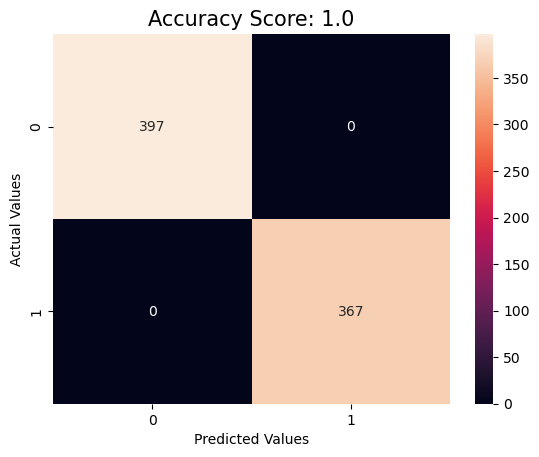

In [26]:
from sklearn.metrics import confusion_matrix as cm

predictions = LR_model.predict(X_test)
score = round(accuracy_score(y_test, predictions), 3)
cm1 = cm(y_test, predictions)
sns.heatmap(cm1, annot=True, fmt=".0f")
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Accuracy Score: {0}'.format(score), size = 15)
plt.show()

In [27]:
from sklearn.metrics import confusion_matrix

print("Confusion matrix:")
print(confusion_matrix(y_test, preds))

Confusion matrix:
[[397   0]
 [  0 367]]
